# 👄 Notebook 03 — Mouth ROI Extraction
Person 2 — feeds the Lip-Sync model

In [3]:
!pip install opencv-python-headless dlib -q
!pip install cmake -q

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, numpy as np, random, urllib.request
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

BASE_DIR   = "/content/drive/MyDrive/Colab Notebooks/deepfake-project"
IN_FRAMES  = os.path.join(BASE_DIR, "data/frames")
OUT_MOUTH  = os.path.join(BASE_DIR, "data/mouth_roi")
MOUTH_SIZE = 96
os.makedirs(OUT_MOUTH, exist_ok=True)

# Download OpenCV face detector model files
if not os.path.exists("/tmp/deploy.prototxt"):
    print("Downloading face detector models...")
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt",
        "/tmp/deploy.prototxt")
    urllib.request.urlretrieve(
        "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel",
        "/tmp/face_model.caffemodel")

face_net = cv2.dnn.readNetFromCaffe("/tmp/deploy.prototxt", "/tmp/face_model.caffemodel")

# No mediapipe needed at all — remove mp_mesh line entirely
print("✅ Config ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Config ready.


In [5]:
# ✅ Mouth ROI using OpenCV face + landmark approach
import urllib.request

# Download face detector (same as notebook 02)
if not os.path.exists("/tmp/deploy.prototxt"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt",
        "/tmp/deploy.prototxt")
    urllib.request.urlretrieve(
        "https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel",
        "/tmp/face_model.caffemodel")

# Download facial landmark model
if not os.path.exists("/tmp/lbfmodel.yaml"):
    urllib.request.urlretrieve(
        "https://github.com/kurnianggoro/GSOC2017/raw/master/data/lbfmodel.yaml",
        "/tmp/lbfmodel.yaml")

face_net      = cv2.dnn.readNetFromCaffe("/tmp/deploy.prototxt", "/tmp/face_model.caffemodel")
landmark_det  = cv2.face.createFacemarkLBF()
landmark_det.loadModel("/tmp/lbfmodel.yaml")

# Mouth landmark indices (out of 68 landmarks: 48-67 are mouth)
MOUTH_POINTS = list(range(48, 68))

def extract_mouth_roi(image, target_size=MOUTH_SIZE):
    h, w  = image.shape[:2]
    blob  = cv2.dnn.blobFromImage(cv2.resize(image,(300,300)),1.0,
                                   (300,300),(104.0,177.0,123.0))
    face_net.setInput(blob)
    dets  = face_net.forward()
    faces = []
    for i in range(dets.shape[2]):
        if dets[0,0,i,2] > 0.5:
            box = dets[0,0,i,3:7] * np.array([w,h,w,h])
            x1,y1,x2,y2 = box.astype(int)
            faces.append((x1,y1,x2-x1,y2-y1))
    if not faces:
        return None
    # Crop bottom third of face as mouth ROI (fast fallback)
    x,y,fw,fh = faces[0]
    mouth_y1  = y + int(fh * 0.60)
    mouth_y2  = y + fh
    mouth_x1  = x + int(fw * 0.15)
    mouth_x2  = x + fw - int(fw * 0.15)
    mouth     = image[mouth_y1:mouth_y2, mouth_x1:mouth_x2]
    if mouth.size == 0:
        return None
    return cv2.resize(mouth, (target_size, target_size))

print("✅ Mouth ROI extractor ready (OpenCV fallback).")

✅ Mouth ROI extractor ready (OpenCV fallback).


In [6]:
def process_split(split):
    in_sub  = os.path.join(IN_FRAMES, split)
    out_sub = os.path.join(OUT_MOUTH,  split)
    os.makedirs(out_sub, exist_ok=True)
    if not os.path.isdir(in_sub): print(f"[SKIP] {in_sub}"); return
    jpegs    = list(Path(in_sub).rglob("*.jpg"))
    ok, fail = 0, 0
    for jp in tqdm(jpegs, desc=split):
        img   = cv2.imread(str(jp))
        if img is None: fail += 1; continue
        mouth = extract_mouth_roi(img)
        if mouth is None: fail += 1; continue
        cv2.imwrite(os.path.join(out_sub, jp.name), mouth)
        ok += 1
    print(f"  {split}: ✅ {ok} saved | ❌ {fail} failed")

for split in ["fake_with_audio", "real_with_audio"]:
    process_split(split)
print("✅ Mouth ROI extraction complete.")

fake_with_audio: 100%|██████████| 1514/1514 [02:25<00:00, 10.41it/s]


  fake_with_audio: ✅ 1454 saved | ❌ 60 failed


real_with_audio: 100%|██████████| 1654/1654 [02:35<00:00, 10.63it/s]

  real_with_audio: ✅ 1610 saved | ❌ 44 failed
✅ Mouth ROI extraction complete.


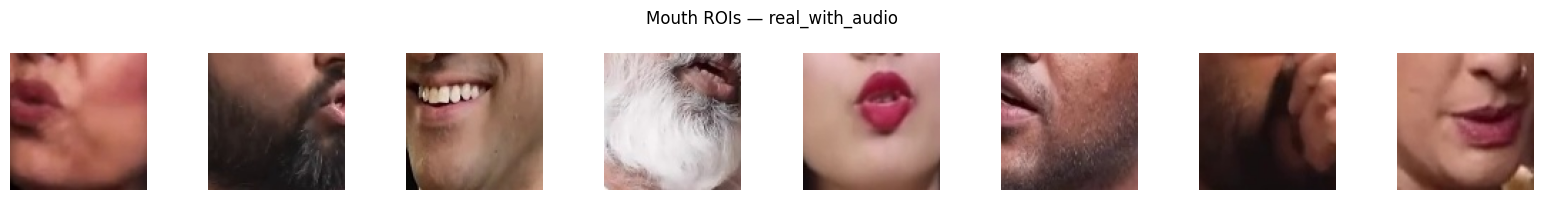

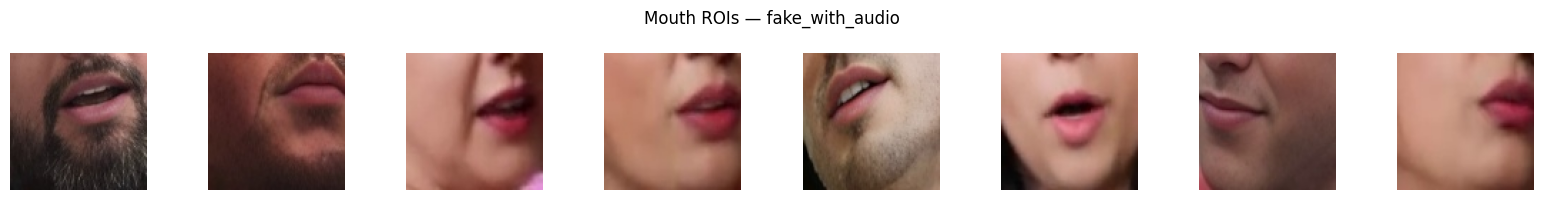

In [7]:
# ✅ Visual check
def show_mouths(split="real_with_audio", n=8):
    d  = os.path.join(OUT_MOUTH, split)
    ps = list(Path(d).glob("*.jpg"))
    if not ps: print(f"No mouths found in {d}"); return
    ps = random.sample(ps, min(n, len(ps)))
    fig, axes = plt.subplots(1, len(ps), figsize=(2*len(ps), 2))
    if len(ps) == 1: axes = [axes]
    for ax, p in zip(axes, ps):
        img = cv2.imread(str(p))
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); ax.axis("off")
    plt.suptitle(f"Mouth ROIs — {split}"); plt.tight_layout(); plt.show()

show_mouths("real_with_audio")
show_mouths("fake_with_audio")